In [192]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [193]:
words = open('/Users/yamini/Downloads/names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [194]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0

itos = {i:s for s,i in stoi.items()}
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [195]:
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [196]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [197]:
C = torch.randn((27, 2))

In [198]:
C[5]

tensor([ 1.2787, -0.7191])

In [199]:
C[X].shape

torch.Size([32, 3, 2])

In [200]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [201]:
w1=torch.randn((6, 100))
b1=torch.randn(100)

In [202]:
h=torch.tanh(emb.view(-1,6)@w1 + b1)

In [203]:
h

tensor([[-1.0000, -0.7003,  0.5909,  ...,  1.0000, -0.8882, -1.0000],
        [-0.9960,  0.8651, -0.1151,  ...,  1.0000,  0.7030, -1.0000],
        [-1.0000, -0.8727,  0.9112,  ...,  0.9784, -0.7495, -0.9250],
        ...,
        [-0.8935,  0.9865, -0.4083,  ..., -0.1098,  0.7815,  0.8222],
        [-0.9987, -0.9200, -0.5381,  ...,  0.9903, -0.8124, -0.8423],
        [-0.8880, -0.2082, -0.5916,  ...,  0.9953, -0.7142, -0.9807]])

In [204]:
h.shape

torch.Size([32, 100])

In [205]:
w2=torch.randn((100, 27))
b2=torch.randn(27)

In [206]:
logits= h@w2+b2

In [207]:
logits.shape

torch.Size([32, 27])

In [208]:
counts=logits.exp()

In [209]:
prob=counts/counts.sum(1, keepdim=True)

In [210]:
prob.shape

torch.Size([32, 27])

In [211]:
loss = -prob[torch.arange(32), Y].log().mean()

In [212]:
X.shape, Y.shape # dataset

(torch.Size([32, 3]), torch.Size([32]))

In [213]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [214]:
sum(p.nelement() for p in parameters) # number of parameters in total

11897

In [215]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [216]:
lri = []
lossi = []
stepi = []

In [217]:
for p in parameters:
  p.requires_grad = True

In [218]:
for i in range(200000):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (32,))
  
  # forward pass
  emb = C[Xtr[ix]] # (32, 3, 10)
  h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 200)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Ytr[ix])
  #print(loss.item())
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  #lr = lrs[i]
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  #lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.log10().item())

#print(loss.item())

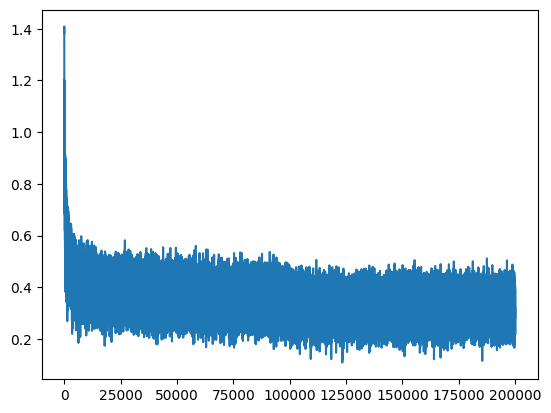

In [219]:
plt.plot(stepi, lossi)

In [220]:
emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1293, grad_fn=<NllLossBackward0>)

In [221]:
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1657, grad_fn=<NllLossBackward0>)

In [ ]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')